In [ ]:
import torch

def generate_chain_dataset(n_samples):
    node_features = []   # (n_samples, 3, 2): [x_i, m_i]
    edge_features = []   # (n_samples, 4, 2): [k_ij, L0_ij]
    targets = []         # (n_samples, 3, 1): aceleraciones

    # Aristas dirigidas: 0->1, 1->0, 1->2, 2->1
    edge_index = torch.tensor([
        [0, 1, 1, 2],
        [1, 0, 2, 1]
    ], dtype=torch.long)

    for _ in range(n_samples):
        # Posiciones ordenadas
        x = torch.sort(torch.rand(3) * 2 - 1).values

        # Masas
        m = 0.1 + 0.9 * torch.rand(3)

        # Constantes de los dos muelles
        k = 0.5 + 1.5 * torch.rand(2)   # evita k casi cero

        # Longitudes naturales
        L0 = 0.1 + 0.5 * torch.rand(2)

        # Fuerzas sobre cada masa
        F = torch.zeros(3)

        # Muelle 0--1
        elong_01 = (x[1] - x[0]) - L0[0]
        F[0] +=  k[0] * elong_01
        F[1] += -k[0] * elong_01

        # Muelle 1--2
        elong_12 = (x[2] - x[1]) - L0[1]
        F[1] +=  k[1] * elong_12
        F[2] += -k[1] * elong_12

        # Aceleraciones
        a = F / m

        # Features nodales: posición y masa
        nodes = torch.stack([x, m], dim=1)  # (3, 2)

        # Features de aristas dirigidas
        edges = torch.tensor([
            [k[0], L0[0]],   # 0 -> 1
            [k[0], L0[0]],   # 1 -> 0
            [k[1], L0[1]],   # 1 -> 2
            [k[1], L0[1]],   # 2 -> 1
        ])

        node_features.append(nodes)
        edge_features.append(edges)
        targets.append(a.unsqueeze(1))

    return (
        torch.stack(node_features),   # (N, 3, 2)
        torch.stack(edge_features),   # (N, 4, 2)
        torch.stack(targets),         # (N, 3, 1)
        edge_index
    )

X_nodes, X_edges, Y, edge_index = generate_chain_dataset(20000)

print(X_nodes.shape)  # torch.Size([20000, 3, 2])
print(X_edges.shape)  # torch.Size([20000, 4, 2])
print(Y.shape)        # torch.Size([20000, 3, 1])
print(edge_index)

torch.Size([20000, 3, 2])
torch.Size([20000, 4, 2])
torch.Size([20000, 3, 1])
tensor([[0, 1, 1, 2],
        [1, 0, 2, 1]])


In [18]:
from torch.utils.data import TensorDataset, DataLoader, random_split

dataset = TensorDataset(X_nodes, X_edges, Y)

n_train = int(0.8 * len(dataset))
n_val = len(dataset) - n_train

train_dataset, val_dataset = random_split(
    dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

print("Muestras de entrenamiento:", len(train_dataset))
print("Muestras de validación:", len(val_dataset))

Muestras de entrenamiento: 16000
Muestras de validación: 4000


In [19]:
sample_nodes = X_nodes[0]
sample_edges = X_edges[0]
sample_target = Y[0]

print("Nodos:")
print(sample_nodes)

print("\nAristas:")
print(sample_edges)

print("\nAceleraciones reales:")
print(sample_target)

print("\nConexiones:")
print(edge_index)

Nodos:
tensor([[-0.7298,  0.3967],
        [-0.0862,  0.6278],
        [ 0.0433,  0.8149]])

Aristas:
tensor([[1.9201, 0.5818],
        [1.9201, 0.5818],
        [1.9612, 0.5783],
        [1.9612, 0.5783]])

Aceleraciones reales:
tensor([[ 0.2990],
        [-1.5909],
        [ 1.0802]])

Conexiones:
tensor([[0, 1, 1, 2],
        [1, 0, 2, 1]])


In [20]:
source = edge_index[0, :]
target = edge_index[1, :]

print("Nodos que envían mensajes:", source)
print("Nodos que reciben mensajes:", target)

Nodos que envían mensajes: tensor([0, 1, 1, 2])
Nodos que reciben mensajes: tensor([1, 0, 2, 1])


In [21]:
nodes_source = sample_nodes[source]
nodes_target = sample_nodes[target]

edge_inputs = torch.cat([
    nodes_source,
    nodes_target,
    sample_edges
], dim=1)

print(edge_inputs)
print(edge_inputs.shape)

tensor([[-0.7298,  0.3967, -0.0862,  0.6278,  1.9201,  0.5818],
        [-0.0862,  0.6278, -0.7298,  0.3967,  1.9201,  0.5818],
        [-0.0862,  0.6278,  0.0433,  0.8149,  1.9612,  0.5783],
        [ 0.0433,  0.8149, -0.0862,  0.6278,  1.9612,  0.5783]])
torch.Size([4, 6])


In [22]:
import torch
import torch.nn as nn

class SpringGNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.message_mlp = nn.Sequential(
            nn.Linear(6, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

In [23]:
import torch
import torch.nn as nn

class SpringGNN(nn.Module):
    def __init__(self, edge_index):
        super().__init__()

        # Guardamos las conexiones dentro del modelo.
        # No son parámetros entrenables, solo indican quién conecta con quién.
        self.register_buffer("edge_index", edge_index)

        # Red que calcula el mensaje de cada arista.
        # Entrada:
        # [x_origen, m_origen, x_destino, m_destino, k, L0] -> 6 datos
        # Salida:
        # un mensaje escalar -> 1 dato
        self.message_mlp = nn.Sequential(
            nn.Linear(6, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, node_features, edge_features):
        """
        node_features: (batch_size, 3, 2)
            Para cada nodo: [posición, masa]

        edge_features: (batch_size, 4, 2)
            Para cada arista: [k, L0]

        return:
            aceleraciones predichas: (batch_size, 3, 1)
        """

        # Separamos nodos origen y nodos destino de cada arista
        source = self.edge_index[0]   # [0, 1, 1, 2]
        target = self.edge_index[1]   # [1, 0, 2, 1]

        # Características de los nodos que envían cada mensaje
        nodes_source = node_features[:, source, :]
        # shape: (batch_size, 4, 2)

        # Características de los nodos que reciben cada mensaje
        nodes_target = node_features[:, target, :]
        # shape: (batch_size, 4, 2)

        # Construimos la información completa de cada arista
        edge_inputs = torch.cat([
            nodes_source,
            nodes_target,
            edge_features
        ], dim=2)
        # shape: (batch_size, 4, 6)

        # Calculamos un mensaje por cada arista
        messages = self.message_mlp(edge_inputs)
        # shape: (batch_size, 4, 1)

        # Preparamos una tensor vacío donde acumular mensajes por nodo
        batch_size = node_features.shape[0]

        acceleration_pred = torch.zeros(
            batch_size,
            3,
            1,
            device=node_features.device,
            dtype=node_features.dtype
        )
        # shape: (batch_size, 3, 1)

        # Sumamos cada mensaje en el nodo que lo recibe
        acceleration_pred.index_add_(1, target, messages)

        return acceleration_pred

Epoch   1/300 | Train Loss: 2.809528 | Val Loss: 1.856885
Epoch  20/300 | Train Loss: 0.234187 | Val Loss: 0.210056
Epoch  40/300 | Train Loss: 0.114968 | Val Loss: 0.097975
Epoch  60/300 | Train Loss: 0.079570 | Val Loss: 0.067599
Epoch  80/300 | Train Loss: 0.063063 | Val Loss: 0.048630
Epoch 100/300 | Train Loss: 0.054101 | Val Loss: 0.049527
Epoch 120/300 | Train Loss: 0.046139 | Val Loss: 0.056878
Epoch 140/300 | Train Loss: 0.044538 | Val Loss: 0.034420
Epoch 160/300 | Train Loss: 0.038307 | Val Loss: 0.028566
Epoch 180/300 | Train Loss: 0.035554 | Val Loss: 0.025056
Epoch 200/300 | Train Loss: 0.031002 | Val Loss: 0.035725
Epoch 220/300 | Train Loss: 0.033792 | Val Loss: 0.024058
Epoch 240/300 | Train Loss: 0.030245 | Val Loss: 0.025139
Epoch 260/300 | Train Loss: 0.026758 | Val Loss: 0.024658
Epoch 280/300 | Train Loss: 0.025942 | Val Loss: 0.030211
Epoch 300/300 | Train Loss: 0.031076 | Val Loss: 0.025363


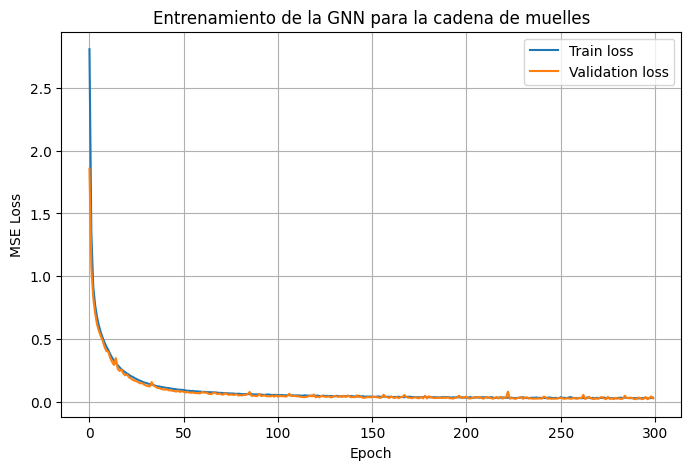

Aceleraciones reales:
tensor([-0.4038,  0.7752, -0.2403])

Aceleraciones predichas:
tensor([-0.3625,  0.6554, -0.3214])


In [24]:
from torch.utils.data import TensorDataset, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Dataset
dataset = TensorDataset(X_nodes, X_edges, Y)

n_train = int(0.8 * len(dataset))
n_val = len(dataset) - n_train

train_dataset, val_dataset = random_split(
    dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

# DataLoaders
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

# Modelo
model = SpringGNN(edge_index)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Entrenamiento
epochs = 300

train_losses = []
val_losses = []

for epoch in range(epochs):

    model.train()
    total_train_loss = 0.0

    for batch_nodes, batch_edges, batch_y in train_loader:

        optimizer.zero_grad()

        pred = model(batch_nodes, batch_edges)

        loss = criterion(pred, batch_y)

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item() * batch_nodes.size(0)

    mean_train_loss = total_train_loss / len(train_dataset)
    train_losses.append(mean_train_loss)

    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for batch_nodes, batch_edges, batch_y in val_loader:

            pred = model(batch_nodes, batch_edges)

            loss = criterion(pred, batch_y)

            total_val_loss += loss.item() * batch_nodes.size(0)

    mean_val_loss = total_val_loss / len(val_dataset)
    val_losses.append(mean_val_loss)

    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1:3d}/{epochs} | "
            f"Train Loss: {mean_train_loss:.6f} | "
            f"Val Loss: {mean_val_loss:.6f}"
        )

# Curva de aprendizaje
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Entrenamiento de la GNN para la cadena de muelles")
plt.legend()
plt.grid(True)
plt.show()

# Prueba con una muestra de validación
model.eval()

with torch.no_grad():
    sample_nodes, sample_edges, sample_y = val_dataset[0]

    pred_y = model(
        sample_nodes.unsqueeze(0),
        sample_edges.unsqueeze(0)
    ).squeeze(0)

print("Aceleraciones reales:")
print(sample_y.squeeze())

print("\nAceleraciones predichas:")
print(pred_y.squeeze())

Muestra aleatoria de validation: 995

Posiciones:
[-0.01033866  0.08422315  0.8496555 ]

Masas:
[0.39215654 0.34356904 0.32750362]

Aceleraciones reales:
[-0.48393276  1.6109222  -1.1104782 ]

Aceleraciones predichas:
[-0.4989853  1.5353153 -1.1543367]


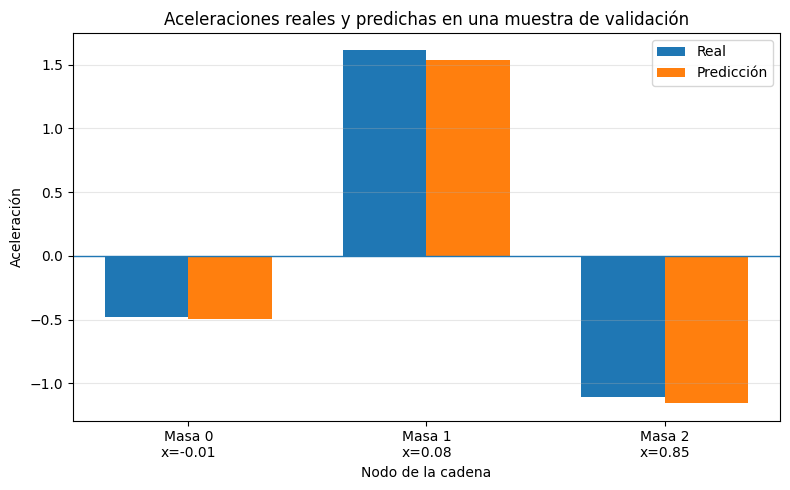

In [25]:
import torch
import matplotlib.pyplot as plt
import random
import numpy as np

# Ponemos el modelo en modo evaluación
model.eval()

# Elegimos una muestra aleatoria del conjunto de validación
random_index = random.randint(0, len(val_dataset) - 1)

sample_nodes, sample_edges, sample_y = val_dataset[random_index]

# Añadimos dimensión de batch:
# (3, 2) -> (1, 3, 2)
# (4, 2) -> (1, 4, 2)
sample_nodes_batch = sample_nodes.unsqueeze(0)
sample_edges_batch = sample_edges.unsqueeze(0)

# Predicción
with torch.no_grad():
    pred_y = model(sample_nodes_batch, sample_edges_batch).squeeze(0)

# Pasamos aceleraciones a numpy para representarlas
real_acc = sample_y.squeeze().numpy()
pred_acc = pred_y.squeeze().numpy()

# Posiciones y masas de la cadena elegida
positions = sample_nodes[:, 0].numpy()
masses = sample_nodes[:, 1].numpy()

print("Muestra aleatoria de validation:", random_index)

print("\nPosiciones:")
print(positions)

print("\nMasas:")
print(masses)

print("\nAceleraciones reales:")
print(real_acc)

print("\nAceleraciones predichas:")
print(pred_acc)

# =========================
# GRÁFICO
# =========================

nodes = np.arange(3)
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    nodes - width / 2,
    real_acc,
    width,
    label="Real"
)

plt.bar(
    nodes + width / 2,
    pred_acc,
    width,
    label="Predicción"
)

plt.axhline(0, linewidth=1)

plt.xticks(
    nodes,
    [
        f"Masa 0\nx={positions[0]:.2f}",
        f"Masa 1\nx={positions[1]:.2f}",
        f"Masa 2\nx={positions[2]:.2f}"
    ]
)

plt.xlabel("Nodo de la cadena")
plt.ylabel("Aceleración")
plt.title("Aceleraciones reales y predichas en una muestra de validación")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()